Isabella Esquivel
March 19, 2026
University of Miami
College of Engineering
Coral Gables, FL 33146


#Heart Failure: Serum Sodium as a Predictor of Ejection Fraction
**Resampling**


# 1. Introduction


#### Background

According to Mayo Clinic, heart failure occurs when the heart muscle does not pump blood as it should, causing blood to back up. This may lead to fluid building in the lungs, causing shortness of breath. The Heart Failure Society of America reported that heart failure was a contributing cause in 425,147 deaths in the United States in 2022, making up 45% of cardiovascular deaths.

Medical records of patients who have undergone heart failure could be used to analyze and identify patterns in patient survival. These clinical factors include ejection fraction, serum creatinine, and serum sodium as well as other demographic factors, such as age and gender. Understanding how these clinical indicators relate is essential to quantifying the risk of death following heart failure and to improve disease management.

##### Prior Studies

Chicco and Jurman(2020) previously demonstrated that the strongest predictors of mortality among heart failure patients were serum creatinine and ejection fraction by using machine learning classification techniques. Additionally, in 2017, Ahmad and colleagues conducted a survival analysis, and found that age, renal dysfunction(having serum creatinine greater than
its normal level 1.5), high blood pressure, high levels of anaemia, and lower values of ejection fraction as the most significant risk factors for death following heart failure.

##### Relevant Previous Analysis Results
Four classification techniques were evaluated using a held-out test set of 299 patients. The full logistic regression model achieved a test accuracy of approximately 78.8%. When the model was reduced to include only ejection fraction and serum creatinine, test accuracy improved to approximately 85.9%.

Linear Discriminant Analysis (LDA) achieved a similar test accuracy of approximately 84.8%. Quadratic Discriminant Analysis (QDA) produced a higher test accuracy of approximately 89.9%, and the Naive Bayes classifier achieved the same test accuracy of approximately 89.9%. Overall, QDA and Naive Bayes demonstrated the strongest predictive performance among the models considered.

#### Study Objective

Previous linear regression studies have found that `serum_sodium `has a statistically significant relationship with `ejection_fraction` with a p value of $0.002268$. Furthermore, previous analysis indicates that `ejection_fraction `may play a substantial role in predicting the event of death following heart failure.

To further extract information from the possible relationship between `serum_sodium` and `ejection_fraction`, resampling techniques will be utilized, including the validation set approach, Leave-One-Out Cross-Validation (LOOCV), k-fold cross-validation, and the bootstrap, which are applied to estimate test error, assess model stability, and evaluate the variability of model coefficients and correlation. These methods provide a more comprehensive understanding of how well the model generalizes to new data and whether increased model complexity improves predictive performance.

# 2. Data and Methods

 ### Dataset Description

The dataset used consists of 299 patients with heart failure. 13 clinical and demographic variables were collected from each patient, including age, sex, anaemia status, diabetes status, high blood pressure, smoking status, serum creatinine, serum sodium, creatinine phosphoinase(CPK), platelet count, follow-up time, ejection fraction, and death event (see table 1 for descriptions).

Table 1

In [12]:
knitr::kable(variable_table, caption = "Table 1. Description of Clinical Variables Included in the Heart Failure Dataset")




Table: Table 1. Description of Clinical Variables Included in the Heart Failure Dataset

|Variable                 |Description                                           |
|:------------------------|:-----------------------------------------------------|
|age                      |Age of the patient (years)                            |
|anaemia                  |Decrease of red blood cells or hemoglobin (boolean)   |
|creatinine_phosphokinase |Level of CPK enzyme in blood (mcg/L)                  |
|diabetes                 |Presence of diabetes (boolean)                        |
|ejection_fraction        |Percentage of blood leaving heart at each contraction |
|high_blood_pressure      |Presence of hypertension (boolean)                    |
|platelets                |Platelets in blood (kiloplatelets/mL)                 |
|sex                      |Sex (binary: 0 = female, 1 = male)                    |
|serum_creatinine         |Serum creatinine level (mg/dL)                      

In [ ]:
HeartFailure <- read.csv("HeartFailure.csv")

In [ ]:
head(HeartFailure)
names(HeartFailure)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,75,0,582,0,20,1,265000,1.9,130,1,0,4,1
2,55,0,7861,0,38,0,263358,1.1,136,1,0,6,1
3,65,0,146,0,20,0,162000,1.3,129,1,1,7,1
4,50,1,111,0,20,0,210000,1.9,137,1,0,7,1
5,65,1,160,1,20,0,327000,2.7,116,0,0,8,1
6,90,1,47,0,40,1,204000,2.1,132,1,1,8,1


[1] "age"                      "anaemia"                 
 [3] "creatinine_phosphokinase" "diabetes"                
 [5] "ejection_fraction"        "high_blood_pressure"     
 [7] "platelets"                "serum_creatinine"        
 [9] "serum_sodium"             "sex"                     
[11] "smoking"                  "time"                    
[13] "DEATH_EVENT"

In [ ]:
?HeartFailure

Summary of each clinical and demographic factor in the Heart Failure Dataset:

In [ ]:
summary(HeartFailure)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

#### Relationship Between Ejection Fraction and Serum Sodium

Since ejection fraction has been identified as a key indicator of survival after heart failure, ejection fraction was modeled as a continuous response variable. The simple linear regression model is given by:

$$
EF_i = \beta_0 + \beta_1 X_i + \varepsilon_i
\tag{1}
$$

where $EF_i$ represents the ejection fraction of patient $i$, $X_i$ represents a clinical predictor, and $\varepsilon_i$ is the random error term.

#####Scatter Plot: Ejection Fraction vs Serum Sodium

A scatter plot of ejection fraction versus serum sodium is used to visually assess the relationship between the predictor and response variable. This step is important for identifying potential linear or non-linear patterns before fitting the regression model.

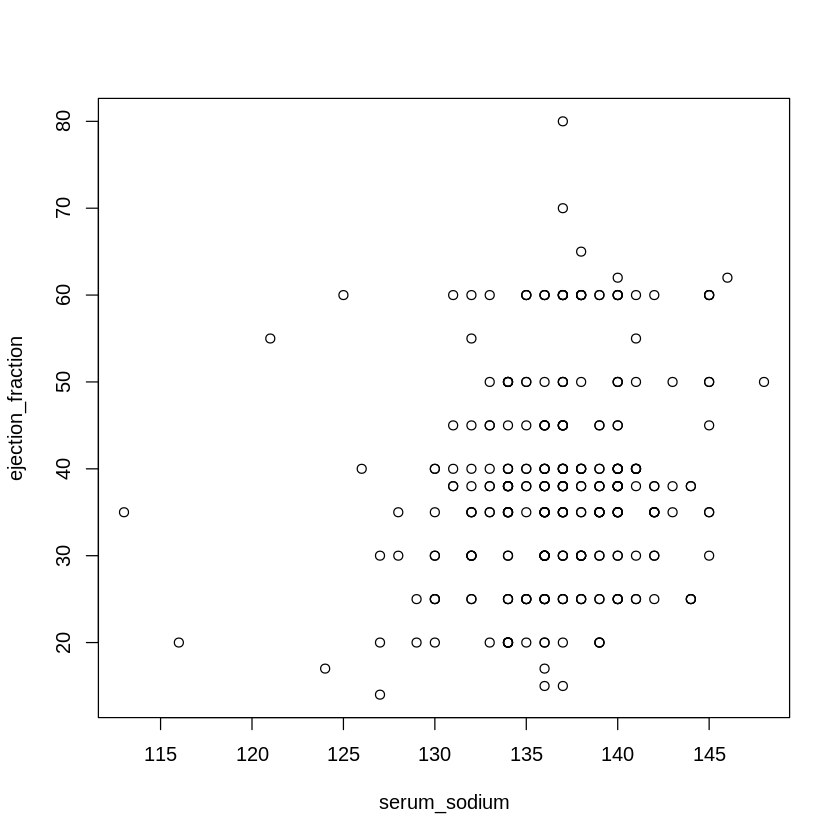

In [ ]:
plot(ejection_fraction ~ serum_sodium, data = HeartFailure)

The plot suggests a weak positive relationship, with substantial variability in ejection fraction across all levels of serum sodium.

**Linear Regression**

Serum sodium was a statistically significant positive predictor of ejection fraction (p = 0.0023). Higher sodium levels were associated with higher ejection fraction values, indicating a small but significant linear relationship.

In [ ]:
lm_sodium1 <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure)
summary(lm_sodium1)


Call:
lm(formula = ejection_fraction ~ serum_sodium, data = HeartFailure)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.260  -8.024  -1.204   6.740  41.740 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  -26.3753    20.9428  -1.259  0.20887   
serum_sodium   0.4718     0.1532   3.079  0.00227 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.67 on 297 degrees of freedom
Multiple R-squared:  0.03094,	Adjusted R-squared:  0.02768 
F-statistic: 9.483 on 1 and 297 DF,  p-value: 0.002268



# 3. Model



### The Validation Set Approach

To evaluate the predictive performance of serum sodium as a predictor of ejection fraction, we implemented the validation set approach. This method estimates test error by splitting the dataset into a training set and a validation set. Before performing the split, the `set.seed()` function was used to ensure reproducibility of results.

In [ ]:
?set.seed

In [ ]:
?sample

A random subset of 149 observations (approximately 50% of the dataset) was selected as the training set. The remaining observations were used as the validation set.

In [ ]:
set.seed(1)
train <- sample(299, 149)

This split allows the model to be trained on one portion of the data and evaluated on unseen data.

Next, a linear regression model was fitted using only the training observations in the Heart Failure dataset.

In [ ]:
lm.fit <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure, subset = train)

This model estimates the relationship between serum sodium and ejection fraction based on the training data. To evaluate its performance, predictions were generated for all observations using the `predict() `function, and the mean squared error (MSE) was computed on the validation set. Note that the `-train` index below selects only the observations that are not in the training set.

In [ ]:
attach(HeartFailure)
mean((ejection_fraction - predict(lm.fit, HeartFailure))[-train]^2)

[1] 132.9652

Therefore, the estimated test MSE for the linear regression fit is $132.96$. The `poly()` function is used to estimate the test error for the quadratic and cubic regressions. The validation set MSE provides an estimate of how well the model generalizes to new data. A lower MSE indicates better predictive performance.

In [ ]:
lm.fit2 <- lm(ejection_fraction ~ poly(serum_sodium, 2), data = HeartFailure,
    subset = train)
mean((ejection_fraction - predict(lm.fit2, HeartFailure))[-train]^2)
lm.fit3 <- lm(ejection_fraction ~ poly(serum_sodium, 3), data = HeartFailure,
    subset = train)
mean((ejection_fraction - predict(lm.fit3, HeartFailure))[-train]^2)

[1] 133.1028

[1] 198.5451

These error rates are $133.10$ and $198.54$, respectively. These models allow for potential non-linear relationships between serum sodium and ejection fraction. However, the results indicate that increasing model complexity does not improve predictive performance. In fact, the linear mode produced the lowest validation error.


#### Different Training Set

If a different training set is selected, somewhat different validation errors may be obtained.To assess the stability of these results, the analysis was repeated using a different random split of the data:

In [ ]:
set.seed(2)
train <- sample(299, 149)
lm.fit <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure, subset = train)
mean((ejection_fraction - predict(lm.fit, HeartFailure))[-train]^2)
lm.fit2 <- lm(ejection_fraction ~ poly(serum_sodium, 2), data = HeartFailure,
    subset = train)
mean((ejection_fraction - predict(lm.fit2,HeartFailure))[-train]^2)
lm.fit3 <- lm(ejection_fraction ~ poly(serum_sodium, 3), data = HeartFailure,
    subset = train)
mean((ejection_fraction- predict(lm.fit3, HeartFailure))[-train]^2)

[1] 158.2397

[1] 159.9323

[1] 161.0609

Using this split of the observations into a training set and a validation set,
we find that the validation set error rates for the models with linear, quadratic, and cubic terms are $158.23$, $159.93$, and $161.06$, respectively.

The linear model produced the lowest validation error, suggesting that adding higher-order polynomial terms does not improve predictive performance for this dataset.

## Leave-One-Out Cross-Validation

To obtain a more reliable estimate of test error, Leave-One-Out Cross-Validation (LOOCV) was implemented. LOOCV is a resampling technique in which each observation is left out once, the model is trained on the remaining data, and the prediction error is computed for the omitted observation. This process is repeated for all observations, and the errors are averaged. The LOOCV estimate can be automatically computed for any generalized linear model   using the `glm()` and `cv.glm()` functions.

In [ ]:
library(boot)

In [ ]:
?cv.glm

Linear - `lm()`

In [ ]:
glm.fit <- glm(ejection_fraction ~ serum_sodium, data = HeartFailure)
coef(glm.fit)

(Intercept) serum_sodium 
 -26.3752914    0.4717929

and

Linear - `glm()`

In [ ]:
lm.fit <- lm(ejection_fraction ~ serum_sodium, data = HeartFailure)
coef(lm.fit)

(Intercept) serum_sodium 
 -26.3752914    0.4717929

The estimated coefficients from the `glm()` model are identical to those obtained using the `lm()` function. However, glm() is used here because it integrates directly with cross-validation tools.

Next, LOOCV was performed using the `cv.glm() `function:

In [ ]:
library(boot)
glm.fit <- glm(ejection_fraction ~ serum_sodium, data = HeartFailure)
cv.err <- cv.glm(HeartFailure, glm.fit)
cv.err$delta

[1] 137.2212 137.2179

 Our cross-validation estimate for the test error is approximately $137.22$. This value represents the average squared prediction error when the model is applied to unseen data.

The validation set approach produced an estimated test MSE of 132.96, while LOOCV yielded a slightly higher estimate of 137.22. Although the validation set estimate is lower, the difference between the two values is relatively small.



This discrepancy arises because the validation set approach relies on a single random split of the data, which can introduce variability depending on how the data is partitioned. In contrast, LOOCV averages the error across all possible training sets of size` n-1` making it a more stable and reliable estimate of test error.

This procedure can be repeated for increasingly complex polynomial fits using LOOCV.
 To automate the process, the  `for()` function is used to iteratively fit polynomial regressions for polynomials of order $i=1$ to $i=10$, compute the associated cross-validation error, and store it in the $i$th element of the vector `cv.error`.
The first step is initializing the vector.

In [ ]:
?rep()

The results show that the lowest cross-validation error occurs for the linear model (degree 1), with error increasing slowly and then substantially as model complexity grew. In particular, higher-degree polynomials produce dramatically larger errors, which may due to overfitting.

In [13]:
cv.error <- rep(0, 10)
for (i in 1:10) {
  glm.fit <- glm(ejection_fraction ~ poly(serum_sodium, i), data = HeartFailure)
  cv.error[i] <- cv.glm(HeartFailure, glm.fit)$delta[1]
}
cv.error

[1]   137.2212   138.0513   139.2489   140.2970   162.6048   247.3309
 [7]   314.4881  3205.3963 14628.5486 16085.3868

These models capture noise in the training data rather than meaningful underlying relationships, leading to poor generalization.



## $k$-Fold Cross-Validation

The `cv.glm()` function can also be used to implement $k$-fold CV. Below $k=10$ is used, a common choice for $k$, on the `HeartFailure` data set.
Once again,a random seed is set and a vector is initialized in which we will store the CV errors corresponding to the polynomial fits of orders one to ten.

In [ ]:
set.seed(17)
cv.error.10 <- rep(0, 10)
for (i in 1:10) {
  glm.fit <- glm(ejection_fraction ~ poly(serum_sodium, i), data = HeartFailure)
  cv.error.10[i] <- cv.glm(HeartFailure, glm.fit, K = 10)$delta[1]
}
cv.error.10

[1]   137.5898   139.2124   140.8802   140.0579   197.9331   235.2302
 [7]   413.7676  3762.8057 14875.6101  1146.9461

To assess the stability of the results, the procedure was repeated with a different random seed:

In [ ]:
set.seed(15)
cv.error.10 <- rep(0, 10)
for (i in 1:10) {
  glm.fit <- glm(ejection_fraction ~ poly(serum_sodium, i), data = HeartFailure)
  cv.error.10[i] <- cv.glm(HeartFailure, glm.fit, K = 10)$delta[1]
}
cv.error.10

[1] 1.368351e+02 1.376924e+02 1.402624e+02 1.426869e+02 1.636669e+02
 [6] 4.091301e+02 2.446613e+02 1.318412e+04 1.623286e+08 4.848098e+04

The results were consistent across both runs, with the linear model (degree 1) yielding the lowest cross-validation error. As the polynomial degree increased, the test error mostly increased as well, particularly for higher-order models.

This behavior mirrors the findings from LOOCV and provides further evidence that increasing model complexity does not improve predictive performance for this dataset.

##The Bootstrap



###Estimating the Accuracy of a Statistic of Interest - Correlation

The bootstrap approach provides a flexible method for estimating the variability of a statistic. The procedure involves two main steps: defining a `function` that computes the statistic of interest, and repeatedly resampling the dataset with replacement to evaluate how the statistic varies across samples.

To demonstrate this approach, serum sodium was treated as `X` and ejection fraction as `Y`, and the correlation between these variables was selected as the statistic of interest. This allows assessment of the strength and stability of their relationship.

In [ ]:
cov.fn <- function(data, index) {
  X <- data$serum_sodium[index]
  Y <- data$ejection_fraction[index]
  (var(Y) - cov(X, Y)) / (var(X) + var(Y) - 2 * cov(X, Y))
}

Applying this function to the full dataset yields the original estimate of the correlation:

In [ ]:
cov.fn(HeartFailure, 1:299)

[1] 0.9271463

The next command  uses the `sample()` function to randomly select
$299$ observations from the range $1$ to $299$, with replacement. This is equivalent
to constructing a new bootstrap data set and recomputing function `cov`
based on the new data set.

In [ ]:
set.seed(7)
cov.fn(HeartFailure, sample(299, 299, replace = T))

[1] 0.9431879

While a single resample provides one alternative estimate, the bootstrap method requires many repetitions to assess variability. A bootstrap analysis can be implemented by repeating this command multiple times, recording all of
the corresponding estimates for `cov`, and computing the resulting
standard deviation.


However, the `boot()` function automates this approach. Below, R = 1000 bootstrap estimates for `cov` are produced:

In [ ]:
boot(HeartFailure, cov.fn, R = 1000)


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = HeartFailure, statistic = cov.fn, R = 1000)


Bootstrap Statistics :
     original        bias    std. error
t1* 0.9271463 -0.0009916424  0.02428574

The output provides the original estimate of the correlation, along with its bootstrap standard error of $0.0242$. The relatively small standard error indicates that the estimated relationship between serum sodium and ejection fraction is consistent across resampled datasets.

###Estimating the Accuracy of a Linear Regression Model

The bootstrap approach can be used to assess the
variability of the coefficient estimates and predictions from a statistical learning method. In this analysis, the bootstrap approach is used in order to assess the variability of
the estimates for $\beta_0$ and $\beta_1$, the intercept and slope terms for the linear regression model
that uses  `serum_sodium` to predict `ejection_fraction` in the `HeartFailure` data set.

These bootstrap-based estimates are compared to the analytical standard errors derived from linear regression theory:

for ${\rm SE}(\hat{\beta}_0)$ and ${\rm SE}(\hat{\beta}_1)$:

$$
SE(\hat{\beta}_1) = \sqrt{ \frac{\hat{\sigma}^2}{\sum (x_i - \bar{x})^2} }
$$

$$
SE(\hat{\beta}_0) = \sqrt{ \hat{\sigma}^2 \left( \frac{1}{n} + \frac{\bar{x}^2}{\sum (x_i - \bar{x})^2} \right) }
$$

$$
\hat{\sigma}^2 = \frac{1}{n - 2} \sum (y_i - \hat{y}_i)^2
$$

These formulas provide theoretical estimates of the variability of the regression coefficients under standard linear model assumptions.



The first step is creating a simple function, `boot.fn()`, which takes in the
`HeartFailure` data set as well as a set of indices for the observations, and
returns the intercept and slope estimates for the linear regression model. Next,this function is applied
to the full set of $299$ observations in order to compute the estimates of $\beta_0$ and $\beta_1$ on the entire data set.

In [ ]:
boot.fn <- function(data, index)
coef(lm(ejection_fraction ~ serum_sodium, data = data, subset = index))
boot.fn(HeartFailure, 1:299)

(Intercept) serum_sodium 
 -26.3752914    0.4717929

Using bootstrap resampling, new datasets are generated by sampling observations with replacement and recomputing the coefficients:

In [ ]:
set.seed(1)
boot.fn(HeartFailure, sample(299, 299, replace = T))
boot.fn(HeartFailure, sample(299, 299, replace = T))

(Intercept) serum_sodium 
 -52.4729744    0.6675086

(Intercept) serum_sodium 
   6.5621550    0.2354076

Next, we use the `boot()` function to compute the standard errors of 1,000 bootstrap estimates for the intercept and slope terms. The variation in these estimates reflects sampling variability.

In [ ]:
boot(HeartFailure, boot.fn, 1000)


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = HeartFailure, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
       original        bias    std. error
t1* -26.3752914  0.1062506733  21.6350313
t2*   0.4717929 -0.0009005807   0.1578552

This indicates that the bootstrap standard error estimate for ${\rm SE}(\hat{\beta}_0)$ is $21.63$, and that the bootstrap estimate for ${\rm SE}(\hat{\beta}_1)$ is $0.1578$.

**Standard Errors for the Regression Coefficients in Linear Model**

In [ ]:
summary(lm(ejection_fraction ~ serum_sodium, data = HeartFailure))$coef

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-26.3752914,20.9427547,-1.259399,0.208874967
serum_sodium,0.4717929,0.1532063,3.079461,0.002267684


The standard errors for the linear regression coefficients are $20.94$ for the intercept and $0.1532$ for the slope. These values differ slightly from the bootstrap estimates, which are $21.63$ and $0.158$, respectively. This discrepancy arises because the analytical formulas rely on assumptions. In contrast, the bootstrap method does not depend on assumptions and instead estimates variability directly from the data.



The bootstrap results indicate that the slope coefficient exhibits relatively low variability compared to its magnitude, while the intercept shows substantial variability, consistent with its lack of statistical significance.

**Bootstrap Quadratic Model**

In [ ]:
boot.fn <- function(data, index)
  coef(
    lm(ejection_fraction ~ serum_sodium + I(serum_sodium^2),
       data = data, subset = index)
  )

set.seed(1)
boot(HeartFailure, boot.fn, 1000)

summary(
  lm(ejection_fraction ~ serum_sodium + I(serum_sodium^2),
     data = HeartFailure)
)$coef


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = HeartFailure, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
         original        bias     std. error
t1* 136.192562393  3.4656346893 327.56826743
t2*  -1.951975441 -0.0494647312   4.82448429
t3*   0.009021798  0.0001751664   0.01776772

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),136.192562393,282.96169854,0.4813109,0.6306511
serum_sodium,-1.951975441,4.20995095,-0.4636575,0.6432339
I(serum_sodium^2),0.009021798,0.01565996,0.5761061,0.5649812


The quadratic model produces coefficient estimates of $136.19$ (intercept), $−1.95$ (linear term), and $0.009$ (squared term), with corresponding bootstrap standard errors of $327.57$, $4.82$, and $0.0178$. The large standard errors relative to the coefficient magnitudes indicate high variability, and the regression p-values ($0.631$, $0.643$, and $0.565$) confirm that none of the terms are statistically significant, possibly demonstrating the model does not provide a reliable fit.

# 4. Results

##Previous Relevant Analysis

The linear regression analysis indicates that serum sodium is a statistically significant predictor of ejection fraction, with an estimated slope of $0.4718$ and a p-value of $0.002268$. This suggests a positive relationship, where higher serum sodium levels are associated with higher ejection fraction values.

##Current Analysis

Using the validation set approach, the estimated test mean squared error (MSE) for the linear model was $132.96$. When polynomial models were considered, the quadratic and cubic models produced higher MSE values of $133.10$ and $198.54$, respectively. Repeating the validation process with a different random split resulted in higher but consistent error estimates of $158.23$, $159.93$, and $161.06$ for the linear, quadratic, and cubic models. Leave-One-Out Cross-Validation (LOOCV) yielded an estimated test error of approximately $137.22$, slightly higher than the initial validation estimate but within a similar range. Similarly, 10-fold cross-validation produced errors near $137.59$ for the linear model, with errors increasing as model complexity increased.

Bootstrap analysis further evaluated the stability of the results. The estimated correlation between serum sodium and ejection fraction was $0.9271$, with a bootstrap standard error of $0.0243$, indicating low variability across resampled datasets. For the linear regression model, the bootstrap standard errors were $21.63$ for the intercept and $0.1578$ for the slope, compared to analytical standard errors of $20.94$ and $0.1532$, respectively.The bootstrap results indicate that the slope coefficient exhibits relatively low variability compared to its magnitude, while the intercept shows much more variability, consistent with its lack of statistical significance.The quadratic model exhibited large bootstrap standard errors ($327.57$, $4.82$, $0.0178$) and non-significant p-values ($0.631$, $0.643$, $0.565$), demonstrating high variability and poor model fit.

#5. Discussion

The use of multiple resampling methods helps clarify how reliable this relationship is beyond the sample data. The validation set approach showed that results can shift depending on how the data are split, which highlights the risk of drawing conclusions from a single partition. In contrast, cross-validation methods provide a more consistent view by repeatedly evaluating the model across different subsets of the data.

Additionally, higher-order polynomial models introduced additional variability without capturing meaningful structure possibly demonstrating overfitting. The similarity in results across LOOCV and k-fold cross-validation suggests that the linear model’s performance is reasonably stable and not overly dependent on a specific split in the data. The bootstrap analysis further supports this by showing that the correlation and slope coefficient remains relatively consistent across resampled datasets.

# 6. Conclusion

This analysis demonstrates that serum sodium is a statistically significant predictor of ejection fraction, but its practical predictive strength may be limited. While a positive relationship exists, the low explanatory power indicates that additional clinical variables may be needed to better capture variation in ejection fraction and in overall heart function.

Resampling methods were important in evaluating the relationship between serum sodium and ejection fraction, because they allowed model performance to be evaluated beyond a single split of the data, reducing the risk of drawing conclusions from results that depend solely on chance. The validation set approach showed that estimates can vary depending on how the data is partitioned, while LOOCV and k-fold cross-validation provided more consistent estimates by averaging across multiple splits. The bootstrap analysis of their relationship further confirmed this as their estimated correlation and slope coefficient remained somewhat stable across 1000 repeated samples. Together, these approaches show that the linear model of serum sodium and ejection fraction provides the most reliable performance without unnecessary complexity and that increasing model flexibility does not improve generalization across unseen data for this dataset.

# 7. Appendix


## Table

In [ ]:
variable_table <- data.frame(
  Variable = c("age",
               "anaemia",
               "creatinine_phosphokinase",
               "diabetes",
               "ejection_fraction",
               "high_blood_pressure",
               "platelets",
               "sex",
               "serum_creatinine",
               "serum_sodium",
               "smoking",
               "time",
               "death_event"),

  Description = c("Age of the patient (years)",
                  "Decrease of red blood cells or hemoglobin (boolean)",
                  "Level of CPK enzyme in blood (mcg/L)",
                  "Presence of diabetes (boolean)",
                  "Percentage of blood leaving heart at each contraction",
                  "Presence of hypertension (boolean)",
                  "Platelets in blood (kiloplatelets/mL)",
                  "Sex (binary: 0 = female, 1 = male)",
                  "Serum creatinine level (mg/dL)",
                  "Serum sodium level (mEq/L)",
                  "Smoking status (boolean)",
                  "Follow-up period (days)",
                  "Death during follow-up (boolean)")
)